## CAPM Analysis: Calculating stock Beta as a Regression

Capital Asset Pricing Model (CAPM) is an extension of the Markowitz’s Modern Portfolio Theory.

This model was developed by the independent works of William Sharpe, Jack Treynor, Jan Mossin, and John Lintner who built on the idea of diversification as introduced by the works of Harry Markowitz.

CAPM attempts to prices securities by examining **the relationship that exists between expected returns and risk**.

The model implies that investors always combine two types of assets or securities; a risk-free asset and a risky asset in the form of a market portfolio of various assets.


CAPM further posits that investors **expect to be rewarded** for holding these risky assets according to the risk inherited for holding on to such assets.

In [ ]:
pip install yfinance

In [ ]:
from scipy import stats
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
%matplotlib inline
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import yfinance as yf


In [ ]:
df_spy = yf.download('SPY', start='2019-03-01', end='2025-03-01')

/tmp/ipython-input-2300637994.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_spy = yf.download('SPY', start='2019-03-01', end='2025-03-01')
[*********************100%***********************]  1 of 1 completed


In [ ]:
df_GLD = yf.download('GLD', start='2019-03-01', end='2025-03-01')

/tmp/ipython-input-290498126.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df_GLD = yf.download('GLD', start='2019-03-01', end='2025-03-01')
[*********************100%***********************]  1 of 1 completed


In [ ]:
df_spy.head()

Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2019-03-01,252.191116,252.604802,250.752177,252.209093,78880500
2019-03-04,251.273819,253.495174,248.971527,253.252364,106494600
2019-03-05,250.932175,251.597701,250.383594,251.399846,59114600
2019-03-06,249.412231,251.058028,249.088484,251.049026,75039800
2019-03-07,247.325775,249.106438,246.480399,248.962542,94885100


In [ ]:
df_GLD.head()

Price,Close,High,Low,Open,Volume
Ticker,GLD,GLD,GLD,GLD,GLD
Date,,,,,
2019-03-01,121.879997,123.959999,121.870003,123.480003,16411700
2019-03-04,121.559998,121.849998,121.180000,121.559998,10272600
2019-03-05,121.720001,121.730003,121.029999,121.379997,7120100
2019-03-06,121.610001,121.639999,121.260002,121.430000,4820400
2019-03-07,121.510002,121.709999,121.180000,121.269997,6088800


In [ ]:
Prices = pd.concat([df_GLD['Close'], df_spy['Close']], axis=1)
Prices.columns = ['GLD', 'SPY']

<Axes: xlabel='Date'>

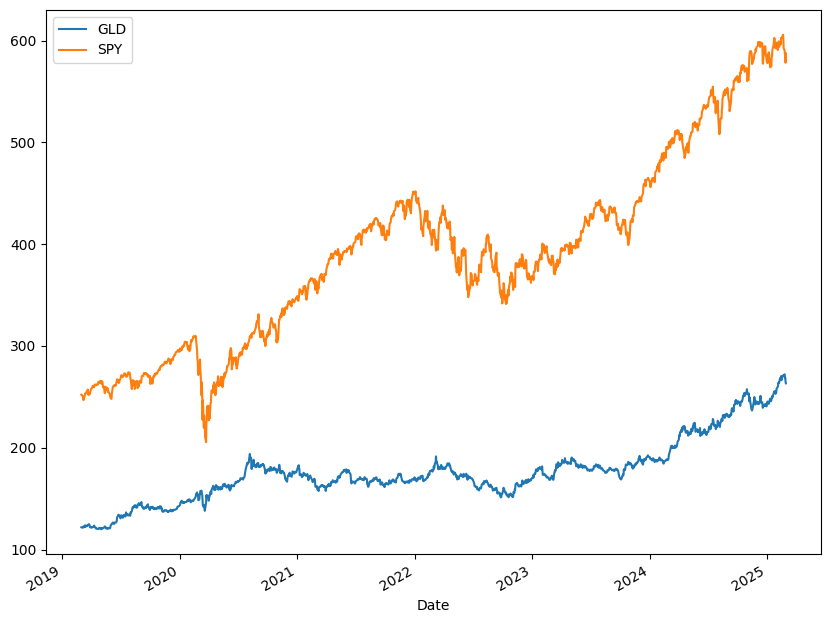

In [ ]:
Prices.plot( figsize=(10,8))

In [ ]:
Prices.head()

,GLD,SPY
Date,,
2019-03-01,121.879997,252.191116
2019-03-04,121.559998,251.273819
2019-03-05,121.720001,250.932175
2019-03-06,121.610001,249.412231
2019-03-07,121.510002,247.325775


In [ ]:
Prices['GLD_acum'] = Prices['GLD']/Prices['GLD'].iloc[0]
Prices['SPY_acum'] = Prices['SPY']/Prices['SPY'].iloc[0]

In [ ]:
Prices.head()

,GLD,SPY,GLD_acum,SPY_acum
Date,,,,
2019-03-01,121.879997,252.191116,1.000000,1.000000
2019-03-04,121.559998,251.273819,0.997374,0.996363
2019-03-05,121.720001,250.932175,0.998687,0.995008
2019-03-06,121.610001,249.412231,0.997785,0.988981
2019-03-07,121.510002,247.325775,0.996964,0.980708


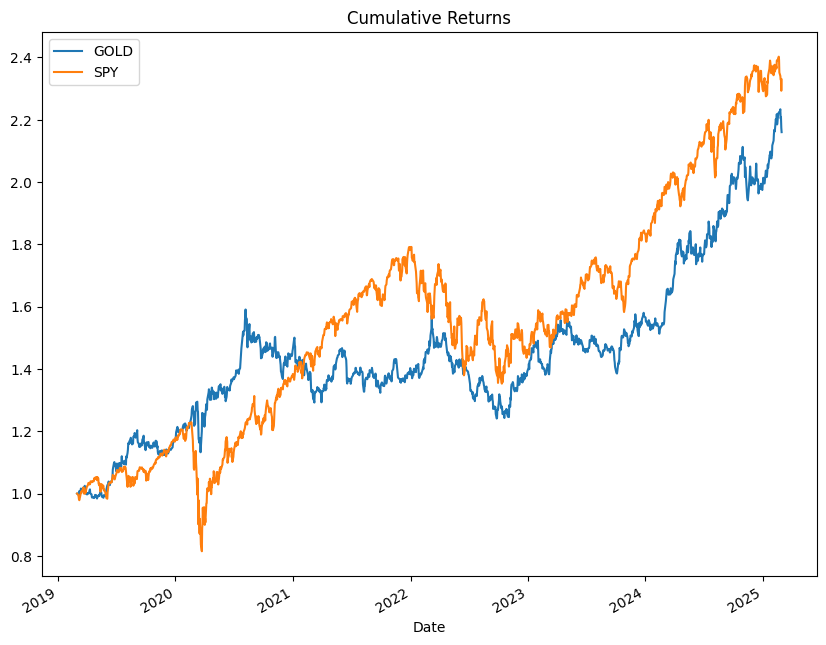

In [ ]:
Prices['GLD_acum'].plot(label = 'GOLD', figsize=(10,8))
Prices['SPY_acum'].plot(label = 'SPY')
plt.title('Cumulative Returns')
plt.legend()

In [ ]:
# check the head of the dataframe
print(Prices.head())

                   GLD         SPY  GLD_acum  SPY_acum
Date                                                  
2019-03-01  121.879997  252.191116  1.000000  1.000000
2019-03-04  121.559998  251.273819  0.997374  0.996363
2019-03-05  121.720001  250.932175  0.998687  0.995008
2019-03-06  121.610001  249.412231  0.997785  0.988981
2019-03-07  121.510002  247.325775  0.996964  0.980708


In [ ]:

Prices['SPY_Ret'] = Prices['SPY'].pct_change()
Prices['GLD_Ret'] = Prices['GLD'].pct_change()

In [ ]:
Prices.head()

,GLD,SPY,GLD_acum,SPY_acum,SPY_Ret,GLD_Ret
Date,,,,,,
2019-03-01,121.879997,252.191116,1.000000,1.000000,NaN,NaN
2019-03-04,121.559998,251.273819,0.997374,0.996363,-0.003637,-0.002626
2019-03-05,121.720001,250.932175,0.998687,0.995008,-0.001360,0.001316
2019-03-06,121.610001,249.412231,0.997785,0.988981,-0.006057,-0.000904
2019-03-07,121.510002,247.325775,0.996964,0.980708,-0.008365,-0.000822


In [ ]:
Prices.dropna(inplace=True)

In [ ]:
Prices.head()

,GLD,SPY,GLD_acum,SPY_acum,SPY_Ret,GLD_Ret
Date,,,,,,
2019-03-04,121.559998,251.273819,0.997374,0.996363,-0.003637,-0.002626
2019-03-05,121.720001,250.932175,0.998687,0.995008,-0.001360,0.001316
2019-03-06,121.610001,249.412231,0.997785,0.988981,-0.006057,-0.000904
2019-03-07,121.510002,247.325775,0.996964,0.980708,-0.008365,-0.000822
2019-03-08,122.839996,246.831207,1.007877,0.978747,-0.002000,0.010946


In [ ]:
model = smf.ols(formula='GLD_Ret ~ SPY_Ret', data=Prices).fit()

In [ ]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                GLD_Ret   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.016
Method:                 Least Squares   F-statistic:                     25.57
Date:                Tue, 10 Feb 2026   Prob (F-statistic):           4.79e-07
Time:                        22:39:58   Log-Likelihood:                 4901.1
No. Observations:                1508   AIC:                            -9798.
Df Residuals:                    1506   BIC:                            -9788.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0005      0.000      2.037      0.0

In [ ]:
# split dependent and independent variable
X = Prices['SPY_Ret']
y = Prices['GLD_Ret']

In [ ]:
model_2 = LinearRegression().fit(X.values.reshape(-1, 1), y.values)

In [ ]:
X = Prices[['SPY_Ret']]
Y = Prices[['GLD_Ret']]

In [ ]:
model_3 = LinearRegression().fit(X,Y)

In [ ]:
model_3.coef_

array([[0.09795242]])

In [ ]:
model_2.coef_

array([0.09795242])

In [ ]:
model_2.intercept_

np.float64(0.0004930622848180045)

In [ ]:
model_2.score(X.values.reshape(-1, 1), y.values)

0.016694041296505202